# Memproses Dataset Gambar dengan TensorFlow

Notebook ini adalah versi pembelajaran berbahasa Indonesia yang mengikuti alur tutorial **Load and preprocess images** dari TensorFlow. Tutorial aslinya dapat diakses [di sini](https://www.tensorflow.org/tutorials/load_data/images).

## 1. Konsep Dasar: Mengapa Data Gambar Perlu Diproses?

Model deep learning tidak membaca gambar seperti manusia. Bagi komputer, gambar adalah kumpulan angka.

Sebuah gambar berwarna biasanya memiliki bentuk:

$$
(\text{tinggi}, \text{lebar}, \text{channel warna})
$$

Contoh:

```text
(180, 180, 3)
```

Artinya:

- `180` = tinggi gambar dalam piksel
- `180` = lebar gambar dalam piksel
- `3` = channel warna RGB: Red, Green, Blue

Nilai piksel gambar biasanya berada pada rentang `0` sampai `255`.

Dalam banyak model neural network, nilai ini biasanya dinormalisasi menjadi rentang `0` sampai `1` agar proses training lebih stabil.

## 2. Setup Library

Kita akan menggunakan beberapa library:

- `tensorflow` untuk membangun pipeline data dan model deep learning.
- `pathlib` untuk mengelola path folder.
- `PIL` untuk membuka gambar.
- `matplotlib` untuk visualisasi gambar.
- `numpy` untuk operasi numerik sederhana.

In [ ]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


## 3. Download Dataset Bunga

Tutorial ini menggunakan dataset gambar bunga. Dataset ini memiliki 5 kelas:

```text
flower_photos/
    daisy/
    dandelion/
    roses/
    sunflowers/
    tulips/
```

Struktur folder seperti ini sangat penting.

Pada klasifikasi gambar berbasis folder, **nama folder sering digunakan sebagai nama kelas**. Misalnya, semua gambar di folder `roses` akan dianggap sebagai kelas `roses`.

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos.tar",
    origin=dataset_url,
    extract=True,
    cache_dir="/content/"
)

data_dir = pathlib.Path(os.path.join(data_dir, "flower_photos")).with_suffix("")
print("Lokasi dataset:", data_dir)

Lokasi dataset: /content/datasets/flower_photos_extracted/flower_photos


## 4. Menghitung Jumlah Gambar

Sebelum membuat model, kita perlu memastikan dataset berhasil diunduh.

Kode berikut menghitung jumlah file gambar `.jpg` di dalam semua subfolder.

In [ ]:
image_count = len(list(data_dir.glob("*/*.jpg")))
print("Jumlah gambar:", image_count)

Jumlah gambar: 3670


## 5. Menampilkan Contoh Gambar

Sebelum training, biasakan untuk melihat beberapa contoh data.

Ini penting karena kadang dataset memiliki masalah, misalnya gambar rusak, label salah, atau format tidak konsisten.

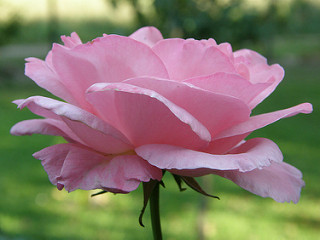

In [ ]:
roses = list(data_dir.glob("roses/*"))

# Menampilkan salah satu gambar mawar
PIL.Image.open(str(roses[0]))

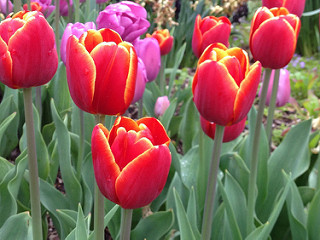

In [ ]:
tulips = list(data_dir.glob("tulips/*"))

# Menampilkan salah satu gambar tulip
PIL.Image.open(str(tulips[0]))

# A. Memuat Data dengan Keras Utility

Cara pertama adalah cara yang paling mudah, yaitu menggunakan:

```python
tf.keras.utils.image_dataset_from_directory()
```

Fungsi ini membaca gambar dari folder, mengubahnya menjadi `tf.data.Dataset`, dan membuat label berdasarkan nama subfolder.

## 6. Menentukan Parameter Dasar

Kita menentukan tiga parameter penting:

- `batch_size`: jumlah gambar yang diproses dalam satu batch.
- `img_height`: tinggi gambar setelah diubah ukurannya.
- `img_width`: lebar gambar setelah diubah ukurannya.

Mengapa ukuran gambar disamakan?

Karena neural network membutuhkan input dengan ukuran yang konsisten. Jika satu gambar berukuran 300x400 dan gambar lain 800x600, model akan sulit memprosesnya dalam satu batch.

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

## 7. Membuat Dataset Training

Kita akan menggunakan 80% data untuk training dan 20% data untuk validasi.

Parameter penting:

- `validation_split=0.2`: 20% data digunakan untuk validasi.
- `subset="training"`: bagian ini dipakai sebagai data latih.
- `seed=123`: agar pembagian data konsisten setiap kali notebook dijalankan.
- `image_size=(img_height, img_width)`: semua gambar diubah menjadi 180x180.
- `batch_size=batch_size`: data dibagi menjadi batch berukuran 32.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


## 8. Membuat Dataset Validasi

Data validasi digunakan untuk mengecek apakah model hanya menghafal data training atau benar-benar belajar pola umum.

Parameter `seed` harus sama dengan dataset training agar pembagian data konsisten.

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


## 9. Melihat Nama Kelas

Nama kelas diambil dari nama subfolder di dalam dataset.

Pada dataset ini, kelasnya adalah jenis-jenis bunga.

In [ ]:
class_names = train_ds.class_names
print("Nama kelas:", class_names)

Nama kelas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## 10. Memahami Bentuk Batch Data

Sekarang kita cek bentuk data.

Satu batch gambar akan memiliki bentuk:

```text
(batch_size, height, width, channel)
```

Dengan parameter kita:

```text
(32, 180, 180, 3)
```

Artinya dalam satu batch terdapat 32 gambar, masing-masing berukuran 180x180 dengan 3 channel warna.

In [ ]:
for image_batch, labels_batch in train_ds.take(1):
    print("Bentuk batch gambar:", image_batch.shape)
    print("Bentuk batch label:", labels_batch.shape)
    print("Contoh label:", labels_batch[:10].numpy())

Bentuk batch gambar: (32, 180, 180, 3)
Bentuk batch label: (32,)
Contoh label: [2 1 4 3 1 2 1 2 4 1]


## 11. Visualisasi Beberapa Gambar dari Dataset

Visualisasi ini membantu kita memahami data yang masuk ke model.

Perhatikan bahwa label masih berupa angka. Angka tersebut akan dipetakan ke `class_names`.

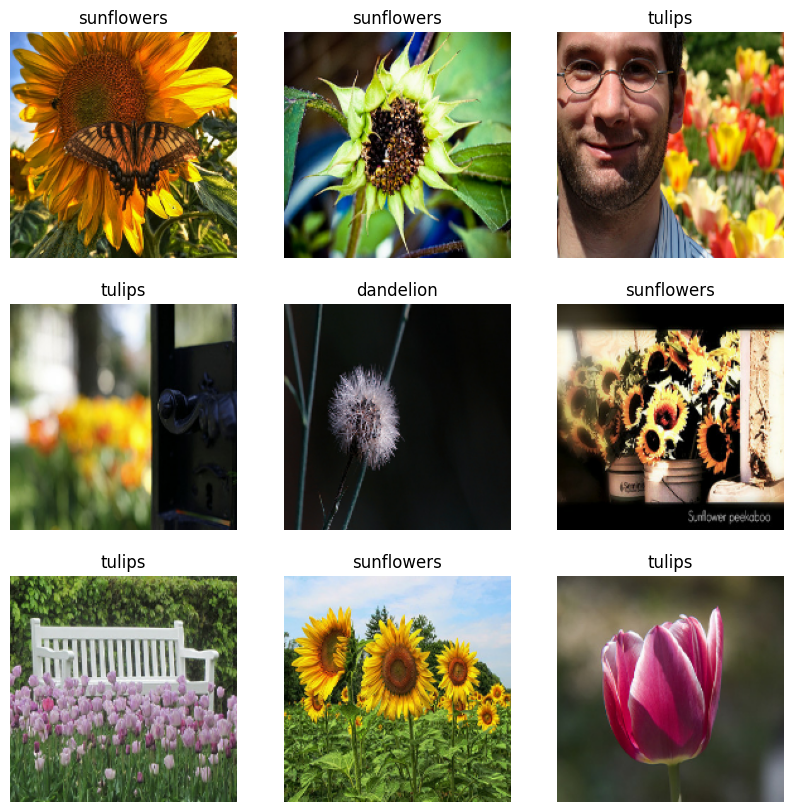

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 12. Normalisasi Nilai Piksel

Gambar biasanya memiliki nilai piksel dari `0` sampai `255`.

Untuk neural network, kita sering mengubahnya ke rentang `0` sampai `1`.

Rumusnya:

$$
\text{nilai baru} = \frac{\text{nilai piksel lama}}{255}
$$

Di TensorFlow, kita bisa menggunakan layer:

```python
tf.keras.layers.Rescaling(1./255)
```

Layer ini bisa dimasukkan langsung ke dalam model.

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]

print("Nilai piksel minimum setelah normalisasi:", np.min(first_image))
print("Nilai piksel maksimum setelah normalisasi:", np.max(first_image))

Nilai piksel minimum setelah normalisasi: 0.0
Nilai piksel maksimum setelah normalisasi: 0.96902645


## 13. Mengoptimalkan Pipeline Data

Saat training model, komputer melakukan dua pekerjaan besar:

1. Membaca dan memproses data.
2. Melatih model.

Jika pembacaan data lambat, GPU/CPU bisa menunggu terlalu lama.

Untuk mengurangi masalah ini, kita gunakan:

- `cache()`: menyimpan data setelah dibaca pertama kali.
- `prefetch()`: menyiapkan batch berikutnya ketika model sedang training batch saat ini.

Ini adalah praktik yang baik ketika menggunakan `tf.data.Dataset`.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# B. Training Model CNN Sederhana

Sekarang kita akan membuat model klasifikasi gambar sederhana.

Model ini bukan model terbaik, tetapi cukup untuk memahami alur kerja:

```text
Dataset gambar
→ Preprocessing
→ CNN
→ Prediksi kelas
```

CNN atau Convolutional Neural Network cocok untuk gambar karena dapat menangkap pola visual seperti tepi, tekstur, bentuk, dan kombinasi objek.

## 14. Membuat Model CNN

Arsitektur model:

1. `Rescaling`: mengubah nilai piksel dari 0–255 menjadi 0–1.
2. `Conv2D`: mencari pola visual lokal.
3. `MaxPooling2D`: mengecilkan ukuran fitur dan mengambil informasi penting.
4. `Flatten`: mengubah fitur 2D menjadi vektor 1D.
5. `Dense`: melakukan klasifikasi.
6. Output layer: menghasilkan skor untuk setiap kelas.

Karena ada 5 kelas bunga, output terakhir memiliki 5 neuron.

In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes)
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,981 (3.14 MB)

 Trainable params: 822,981 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

## 15. Compile Model

Sebelum training, model perlu dikompilasi.

Kita menggunakan:

- `optimizer='adam'`: algoritma untuk memperbarui bobot model.
- `SparseCategoricalCrossentropy`: loss function untuk klasifikasi multi-kelas dengan label integer.
- `from_logits=True`: karena output layer belum menggunakan softmax.
- `accuracy`: metrik untuk melihat persentase prediksi benar.

In [ ]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## 16. Training Model

Kita latih selama 3 epoch agar cepat.

`epoch` berarti satu putaran penuh model melihat seluruh data training.

Untuk dataset nyata, jumlah epoch biasanya perlu disesuaikan. Jika terlalu sedikit, model belum belajar. Jika terlalu banyak, model bisa overfitting.

In [ ]:
epochs = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3961 - loss: 1.3727 - val_accuracy: 0.5232 - val_loss: 1.1484
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.5555 - loss: 1.0813 - val_accuracy: 0.6035 - val_loss: 1.0284
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6386 - loss: 0.9227 - val_accuracy: 0.6308 - val_loss: 0.9525


## 17. Visualisasi Hasil Training

Grafik ini membantu kita melihat apakah model belajar.

Perhatikan dua hal:

1. Jika akurasi training naik, model sedang belajar dari data training.
2. Jika akurasi validasi jauh lebih rendah dari training, kemungkinan terjadi overfitting.

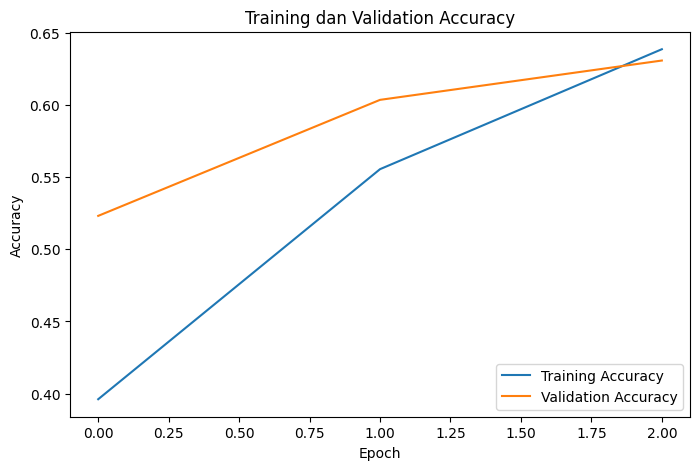

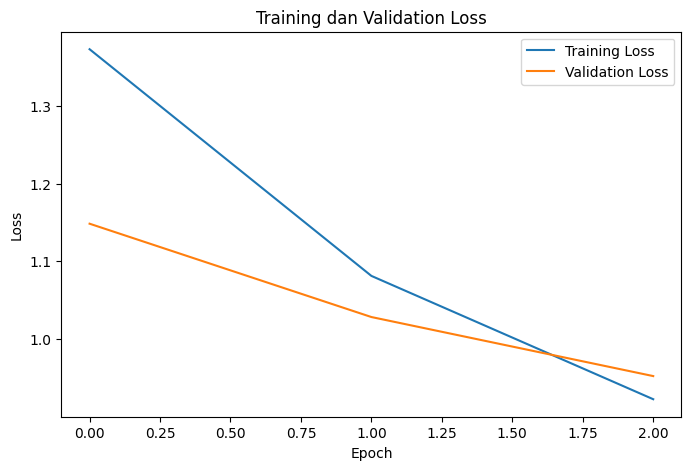

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 18. Prediksi Satu Batch Gambar

Sekarang kita coba prediksi beberapa gambar dari data validasi.

Karena model menghasilkan `logits`, kita ubah dulu menjadi probabilitas menggunakan `softmax`.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step


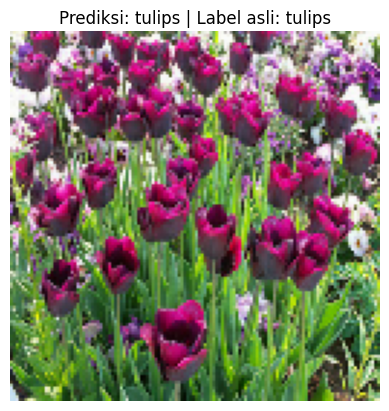

Probabilitas tiap kelas:
daisy       : 0.0071
dandelion   : 0.0001
roses       : 0.0464
sunflowers  : 0.0056
tulips      : 0.9407


In [ ]:
for images, labels in val_ds.take(1):
    logits = model.predict(images)
    probabilities = tf.nn.softmax(logits)

    predicted_label = np.argmax(probabilities[0])
    true_label = labels[0].numpy()

    plt.imshow(images[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Prediksi: {class_names[predicted_label]} | Label asli: {class_names[true_label]}"
    )
    plt.show()

    print("Probabilitas tiap kelas:")
    for name, prob in zip(class_names, probabilities[0].numpy()):
        print(f"{name:12s}: {prob:.4f}")

# C. Membuat Pipeline Manual dengan `tf.data`

Pada bagian sebelumnya, kita menggunakan fungsi praktis `image_dataset_from_directory`.

Sekarang kita akan membangun pipeline secara manual untuk lebih memahami proses di baliknya:

```text
file path
→ baca file
→ decode gambar
→ resize gambar
→ ambil label dari nama folder
→ bentuk dataset
```

Bagian ini lebih teknis, tetapi penting untuk memahami cara kerja pipeline data.

## 19. Membuat Daftar Path File Gambar

`tf.data.Dataset.list_files()` dapat digunakan untuk membuat dataset berisi daftar path file.

In [ ]:
list_ds = tf.data.Dataset.list_files(str(data_dir / "*/*"), shuffle=False)

# Acak urutan file agar kelas tidak berurutan terus
list_ds = list_ds.shuffle(image_count, reshuffle_each_iteration=False)

for file_path in list_ds.take(5):
    print(file_path.numpy())

b'/content/datasets/flower_photos_extracted/flower_photos/sunflowers/16143151468_4f3c033e33.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/dandelion/13887066460_64156a9021.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/roses/9164900485_605aa12da8.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/tulips/2333321040_3960b9d67e_n.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/roses/15738649506_2b4c2fd933_m.jpg'


## 20. Membuat Nama Kelas dari Struktur Folder

Kita ambil nama folder sebagai nama kelas.

`LICENSE.txt` bukan kelas, sehingga perlu dikeluarkan.

In [ ]:
class_names_manual = np.array(
    sorted([
        item.name for item in data_dir.glob("*")
        if item.name != "LICENSE.txt"
    ])
)

print(class_names_manual)

['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


## 21. Membagi Data Training dan Validasi secara Manual

Kita gunakan 20% data untuk validasi.

In [ ]:
val_size = int(image_count * 0.2)

manual_val_ds = list_ds.take(val_size)
manual_train_ds = list_ds.skip(val_size)

print("Jumlah data training:", tf.data.experimental.cardinality(manual_train_ds).numpy())
print("Jumlah data validasi:", tf.data.experimental.cardinality(manual_val_ds).numpy())

Jumlah data training: 2936
Jumlah data validasi: 734


## 22. Fungsi untuk Mengambil Label dari Path

Contoh path:

```text
.../flower_photos/roses/image_001.jpg
```

Bagian `roses` adalah nama kelas.

Maka fungsi `get_label()` akan mengambil nama folder sebelum nama file.

In [ ]:
def get_label(file_path):
    # Pecah path berdasarkan separator folder.
    parts = tf.strings.split(file_path, os.path.sep)

    # parts[-2] adalah nama folder kelas.
    one_hot = parts[-2] == class_names_manual

    # Ubah one-hot menjadi label integer.
    return tf.argmax(one_hot)

## 23. Fungsi untuk Membaca dan Mengubah Ukuran Gambar

Gambar di disk masih berupa file terkompresi seperti `.jpg`.

Agar bisa masuk ke model, file perlu:

1. Dibaca sebagai string byte.
2. Di-decode menjadi tensor gambar.
3. Diubah ukurannya menjadi 180x180.

In [ ]:
def decode_img(img):
    # Decode file JPG menjadi tensor 3D dengan 3 channel warna.
    img = tf.io.decode_jpeg(img, channels=3)

    # Resize gambar agar ukurannya seragam.
    img = tf.image.resize(img, [img_height, img_width])

    return img


def process_path(file_path):
    label = get_label(file_path)

    # Baca file gambar mentah.
    img = tf.io.read_file(file_path)

    # Decode dan resize gambar.
    img = decode_img(img)

    return img, label

## 24. Menerapkan Fungsi ke Seluruh Dataset

Kita gunakan `map()` agar setiap path file diubah menjadi pasangan:

```text
(image, label)
```

`num_parallel_calls=AUTOTUNE` membantu TensorFlow memproses beberapa gambar secara paralel jika memungkinkan.

In [ ]:
manual_train_ds = manual_train_ds.map(process_path, num_parallel_calls=AUTOTUNE)
manual_val_ds = manual_val_ds.map(process_path, num_parallel_calls=AUTOTUNE)

for image, label in manual_train_ds.take(1):
    print("Bentuk gambar:", image.numpy().shape)
    print("Label:", label.numpy())
    print("Nama kelas:", class_names_manual[label.numpy()])

Bentuk gambar: (180, 180, 3)
Label: 0
Nama kelas: daisy


## 25. Mengonfigurasi Pipeline Manual

Untuk training, dataset sebaiknya:

1. Di-cache.
2. Diacak.
3. Dibagi menjadi batch.
4. Di-prefetch.

In [ ]:
def configure_for_performance(ds, shuffle=False):
    ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=AUTOTUNE)

    return ds


manual_train_ds = configure_for_performance(manual_train_ds, shuffle=True)
manual_val_ds = configure_for_performance(manual_val_ds, shuffle=False)

## 26. Visualisasi Dataset Manual

Sekarang kita lihat apakah pipeline manual menghasilkan gambar dan label dengan benar.

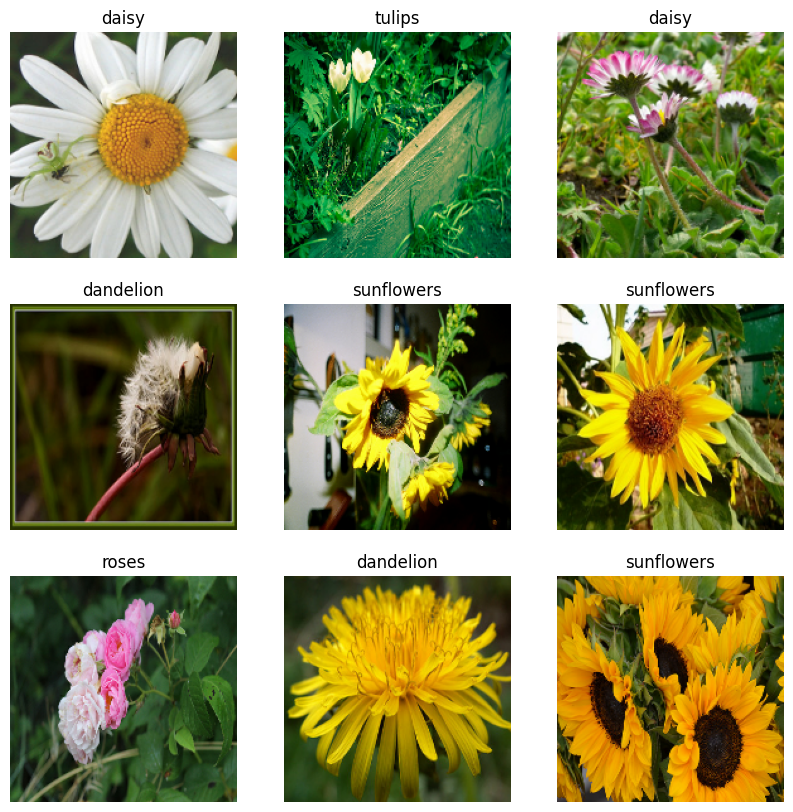

In [ ]:
image_batch, label_batch = next(iter(manual_train_ds))

plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names_manual[label_batch[i]])
    plt.axis("off")

## 27. Training Lanjutan dengan Dataset Manual

Dataset manual memiliki format yang sama dengan dataset dari `image_dataset_from_directory`, yaitu pasangan:

```text
(image_batch, label_batch)
```

Karena itu, dataset ini juga bisa digunakan untuk training model.

In [ ]:
# Latih sebentar lagi menggunakan pipeline manual.
# Pada praktik nyata, biasanya kita membuat model baru agar eksperimennya bersih.
history_manual = model.fit(
    manual_train_ds,
    validation_data=manual_val_ds,
    epochs=1
)

92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7442 - loss: 0.6751 - val_accuracy: 0.7180 - val_loss: 0.7178


# D. Load Dataset dengan TensorFlow Datasets

TensorFlow Datasets atau `tensorflow_datasets` menyediakan banyak dataset siap pakai.

Bagian ini opsional. Jika library belum tersedia, jalankan:

```python
%pip install tensorflow-datasets
```

Dataset yang digunakan tetap `tf_flowers`, tetapi sumbernya dari katalog TensorFlow Datasets.

In [ ]:
# Jalankan cell ini jika tensorflow_datasets belum tersedia:
# %pip install tensorflow-datasets

In [ ]:
try:
    import tensorflow_datasets as tfds
    print("tensorflow_datasets tersedia.")
except ImportError:
    print("tensorflow_datasets belum terpasang. Jalankan: %pip install tensorflow-datasets")

tensorflow_datasets tersedia.


## 28. Memuat Dataset `tf_flowers` dari TensorFlow Datasets

`tf_flowers` hanya memiliki satu split utama, sehingga kita bagi sendiri:

- `train[:80%]` untuk training
- `train[80%:]` untuk validasi

In [ ]:
# Jalankan hanya jika tensorflow_datasets sudah terpasang.

try:
    (tfds_train, tfds_val), tfds_info = tfds.load(
        "tf_flowers",
        split=["train[:80%]", "train[80%:]"],
        as_supervised=True,
        with_info=True
    )

    tfds_class_names = tfds_info.features["label"].names
    print("Nama kelas dari TFDS:", tfds_class_names)
    print("Jumlah kelas:", len(tfds_class_names))

except NameError:
    print("Library tfds belum tersedia.")

AttributeError: module 'tensorflow_datasets' has no attribute 'load'

## 29. Preprocessing Dataset dari TFDS

Dataset dari TFDS juga perlu dibuat seragam:

1. Resize gambar menjadi 180x180.
2. Batch data.
3. Cache dan prefetch.

In [ ]:
def preprocess_tfds(image, label):
    image = tf.image.resize(image, [img_height, img_width])
    return image, label


try:
    tfds_train = (
        tfds_train
        .map(preprocess_tfds, num_parallel_calls=AUTOTUNE)
        .cache()
        .shuffle(1000)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    tfds_val = (
        tfds_val
        .map(preprocess_tfds, num_parallel_calls=AUTOTUNE)
        .cache()
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )

    print("Pipeline TFDS siap digunakan.")

except NameError:
    print("Dataset TFDS belum berhasil dimuat.")

Dataset TFDS belum berhasil dimuat.


## 30. Membuat Model Baru untuk Dataset TFDS

Kita buat fungsi agar model dapat dibuat ulang dengan mudah.

Ini adalah kebiasaan baik dalam eksperimen machine learning.

In [ ]:
def build_simple_cnn(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(img_height, img_width, 3)),
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes)
    ])

    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [ ]:
try:
    model_tfds = build_simple_cnn(len(tfds_class_names))

    history_tfds = model_tfds.fit(
        tfds_train,
        validation_data=tfds_val,
        epochs=3
    )

except NameError:
    print("Lewati cell ini jika TFDS belum berhasil dimuat.")

Lewati cell ini jika TFDS belum berhasil dimuat.


# Bagian E — Perbaikan untuk Mengurangi Overfitting

Pada model sederhana, validasi bisa lebih rendah dari training. Ini tanda awal model mungkin terlalu menghafal data training.

Dua teknik yang sering digunakan:

1. **Data Augmentation**  
   Membuat variasi gambar secara acak, misalnya flip dan rotasi kecil.

2. **Dropout**  
   Mematikan sebagian neuron secara acak selama training agar model tidak terlalu bergantung pada pola tertentu.

Kode berikut adalah contoh model yang sedikit lebih baik.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes)
])

improved_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Jalankan jika ingin membandingkan dengan model sebelumnya.
# Untuk menghemat waktu, jumlah epoch dibuat kecil.

history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.4063 - loss: 1.3429 - val_accuracy: 0.5640 - val_loss: 1.1004
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.5381 - loss: 1.1359 - val_accuracy: 0.5886 - val_loss: 1.0321
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.6080 - loss: 1.0159 - val_accuracy: 0.6362 - val_loss: 0.9553


# Ringkasan Materi

Dalam notebook ini, kita telah mempelajari:

1. Dataset gambar sebaiknya memiliki struktur satu folder per kelas.
2. `image_dataset_from_directory()` adalah cara mudah untuk membaca dataset gambar dari folder.
3. Gambar perlu diubah ke ukuran yang sama sebelum masuk ke model.
4. Label dapat dibuat otomatis berdasarkan nama folder.
5. Nilai piksel biasanya dinormalisasi dari `0–255` menjadi `0–1`.
6. `cache()` dan `prefetch()` membantu pipeline data berjalan lebih efisien.
7. CNN sederhana dapat digunakan untuk klasifikasi gambar.
8. Pipeline manual dengan `tf.data` memberi kontrol lebih besar.
9. TensorFlow Datasets menyediakan dataset siap pakai.
10. Data augmentation dan dropout dapat membantu mengurangi overfitting.

# Latihan

## Latihan 1. Ubah Ukuran Gambar

Ubah:

```python
img_height = 180
img_width = 180
```

menjadi:

```python
img_height = 128
img_width = 128
```

Lalu jalankan ulang notebook.

Jawab pertanyaan berikut:

1. Apakah training menjadi lebih cepat?
2. Apakah akurasi berubah?
3. Mengapa ukuran gambar dapat memengaruhi waktu training?

---

## Latihan 2. Ubah Batch Size

Coba nilai batch size berikut:

```python
batch_size = 16
batch_size = 64
```

Amati:

1. Mana yang lebih cepat?
2. Apakah hasil akurasi berubah?
3. Apa kemungkinan kelebihan dan kekurangan batch size besar?

---

## Latihan 3. Tambahkan Data Augmentation

Tambahkan layer berikut ke model:

```python
tf.keras.layers.RandomContrast(0.2)
```

Pertanyaan:

1. Apakah validation accuracy meningkat?
2. Apakah training menjadi lebih lambat?
3. Mengapa data augmentation dapat membantu generalisasi?

---

## Latihan 4. Prediksi Gambar Baru dari Internet atau Komputer

Gunakan satu gambar bunga baru, lalu prediksi kelasnya.

Petunjuk:

```python
img_path = "path_ke_gambar.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "Gambar ini kemungkinan besar adalah {} dengan confidence {:.2f}%."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
```

---

## Latihan 5. Gunakan Dataset Sendiri

Buat folder seperti ini:

```text
dataset_saya/
    kelas_1/
        gambar1.jpg
        gambar2.jpg
    kelas_2/
        gambar1.jpg
        gambar2.jpg
```

Lalu ubah:

```python
data_dir = pathlib.Path("dataset_saya")
```

Pertanyaan:

1. Apakah nama kelas terbaca otomatis?
2. Apakah jumlah gambar setiap kelas seimbang?
3. Apa yang terjadi jika satu kelas memiliki jauh lebih sedikit gambar?

## Latihan 1. Ubah Ukuran Gambar

Ubah:

```python
img_height = 180
img_width = 180
```

menjadi:

```python
img_height = 128
img_width = 128
```

In [ ]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos.tar",
    origin=dataset_url,
    extract=True,
    cache_dir="/content/"
)

data_dir = pathlib.Path(os.path.join(data_dir, "flower_photos")).with_suffix("")
print("Lokasi dataset:", data_dir)

Lokasi dataset: /content/datasets/flower_photos_extracted/flower_photos


In [ ]:
batch_size = 32
img_height = 128
img_width = 128

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
val_size = int(image_count * 0.2)

manual_val_ds = list_ds.take(val_size)
manual_train_ds = list_ds.skip(val_size)

print("Jumlah data training:", tf.data.experimental.cardinality(manual_train_ds).numpy())
print("Jumlah data validasi:", tf.data.experimental.cardinality(manual_val_ds).numpy())

Jumlah data training: 3670
Jumlah data validasi: 0


In [ ]:
list_ds = tf.data.Dataset.list_files(str(data_dir / "*/*"), shuffle=False)

# Acak urutan file agar kelas tidak berurutan terus
list_ds = list_ds.shuffle(image_count, reshuffle_each_iteration=False)

for file_path in list_ds.take(5):
    print(file_path.numpy())

b'/content/datasets/flower_photos_extracted/flower_photos/daisy/10140303196_b88d3d6cec.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/daisy/10172379554_b296050f82_n.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/daisy/102841525_bd6628ae3c.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/daisy/1031799732_e7f4008c03.jpg'
b'/content/datasets/flower_photos_extracted/flower_photos/daisy/10391248763_1d16681106_n.jpg'


In [ ]:
class_names_manual = np.array(
    sorted([
        item.name for item in data_dir.glob("*")
        if item.name != "LICENSE.txt"
    ])
)

print(class_names_manual)

['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


In [ ]:
def get_label(file_path):
    # Pecah path berdasarkan separator folder.
    parts = tf.strings.split(file_path, os.path.sep)

    # parts[-2] adalah nama folder kelas.
    one_hot = parts[-2] == class_names_manual

    # Ubah one-hot menjadi label integer.
    return tf.argmax(one_hot)

In [ ]:
def decode_img(img):
    # Decode file JPG menjadi tensor 3D dengan 3 channel warna.
    img = tf.io.decode_jpeg(img, channels=3)

    # Resize gambar agar ukurannya seragam.
    img = tf.image.resize(img, [img_height, img_width])

    return img


def process_path(file_path):
    label = get_label(file_path)

    # Baca file gambar mentah.
    img = tf.io.read_file(file_path)

    # Decode dan resize gambar.
    img = decode_img(img)

    return img, label

In [ ]:
manual_train_ds = manual_train_ds.map(process_path, num_parallel_calls=AUTOTUNE)
manual_val_ds = manual_val_ds.map(process_path, num_parallel_calls=AUTOTUNE)

for image, label in manual_train_ds.take(1):
    print("Bentuk gambar:", image.numpy().shape)
    print("Label:", label.numpy())
    print("Nama kelas:", class_names_manual[label.numpy()])

Bentuk gambar: (128, 128, 3)
Label: 0
Nama kelas: daisy



Jawab pertanyaan berikut:

1. Apakah training menjadi lebih cepat?

   Jawaban : menurut saya, training menjadi lebih cepat karena ukuran gambar diubah dari img_height = 180 img_width = 180 menjadi img_height = 128 img_width = 128, sehingga jumlah piksel yang diproses menjadi lebih sedikit

2. Apakah akurasi berubah?

   Jawaban : menurut saya, akurasi dapat berubah karena akurasi menjadi sedikit menurun atau tetap stabil tergantung pada dataset dan model yang digunakan. Gambar yang berukuran lebih kecil memiliki detail yang lebih sedikit dibandingkan dengan gambar yang berukuran lebih besar

3. Mengapa ukuran gambar dapat memengaruhi waktu training?

   Jawaban : ukuran gambar dapat memengaruhi waktu training karena semakin besar resolusi gambar dan semakin banyak piksel yang harus diproses oleh model. Proses komputasi membutuhkan waktu dan memori yang lebih besar. Gambar dengan ukuran yang lebih kecil memiliki jumlah piksel yang lebih sedikit sehingga proses training menjadi lebih cepat

## Latihan 2. Ubah Batch Size

Coba nilai batch size berikut:

```python
batch_size = 16
batch_size = 64
```



In [ ]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos.tar",
    origin=dataset_url,
    extract=True,
    cache_dir="/content/"
)

data_dir = pathlib.Path(os.path.join(data_dir, "flower_photos")).with_suffix("")
print("Lokasi dataset:", data_dir)

Lokasi dataset: /content/datasets/flower_photos_extracted/flower_photos


In [ ]:
batch_size = 16
img_height = 128
img_width = 128

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Nama kelas:", class_names)

Nama kelas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
for image_batch, labels_batch in train_ds.take(1):
    print("Bentuk batch gambar:", image_batch.shape)
    print("Bentuk batch label:", labels_batch.shape)
    print("Contoh label:", labels_batch[:10].numpy())

Bentuk batch gambar: (32, 128, 128, 3)
Bentuk batch label: (32,)
Contoh label: [2 1 4 3 1 2 1 2 4 1]


In [ ]:
batch_size = 64
img_height = 128
img_width = 128

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Nama kelas:", class_names)

Nama kelas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
for image_batch, labels_batch in train_ds.take(1):
    print("Bentuk batch gambar:", image_batch.shape)
    print("Bentuk batch label:", labels_batch.shape)
    print("Contoh label:", labels_batch[:10].numpy())

Bentuk batch gambar: (64, 128, 128, 3)
Bentuk batch label: (64,)
Contoh label: [1 0 4 3 1 2 0 4 4 1]


Amati:

1. Mana yang lebih cepat?

   Jawaban : batch_size = 64 lebih cepat dibandingkan batch_size = 16 karena dalam satu proses training model memproses lebih banyak gambar

2. Apakah hasil akurasi berubah?

   Jawaban : menurut saya, hasil akurasi dapat berubah karena perubahan batch size dapat memengaruhi proses pembelajaran model. Hasilnya bergantung pada dataset, model, dan jumlah epoch yang digunakan

3. Apa kemungkinan kelebihan dan kekurangan batch size besar?

   Jawaban : kelebihan batch size besar : training lebih cepat karena jumlah pengulangan dalam setiap epoch menjadi lebih sedikit
   
   kekurangan batch size besar : membutuhkan memori yang lebih besar


## Latihan 3. Tambahkan Data Augmentation

Tambahkan layer berikut ke model:

```python
tf.keras.layers.RandomContrast(0.2)
```



In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2)
])

improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes)
])

improved_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_16 (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_15 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Jalankan jika ingin membandingkan dengan model sebelumnya.
# Untuk menghemat waktu, jumlah epoch dibuat kecil.

history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.3948 - loss: 1.3709 - val_accuracy: 0.5327 - val_loss: 1.1577
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.5157 - loss: 1.1564 - val_accuracy: 0.5845 - val_loss: 1.0740
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.5824 - loss: 1.0559 - val_accuracy: 0.6104 - val_loss: 0.9828


Pertanyaan:

1. Apakah validation accuracy meningkat?

   Jawaban : menurut saya, validation accuracy meningkat karena data augmentation membuat model berlatih menggunakan variasi gambar yang lebih beragam sehingga model dapat mengenali data yang baru. Peningkatan akurasi bergantung pada dataset dan model yang digunakan

2. Apakah training menjadi lebih lambat?

   Jawaban : menurut saya, training menjadi lebih lambat karena setiap gambar mengalami proses augmentasi membuat variasi gambar secara acak, misalnya flip dan rotasi kecil.

3. Mengapa data augmentation dapat membantu generalisasi?

   Jawaban : data augmentation dapat membantu generalisasi karena menghasilkan beberapa variasi dari gambar asli selama proses training

## Latihan 4. Prediksi Gambar Baru dari Internet atau Komputer

Gunakan satu gambar bunga baru, lalu prediksi kelasnya.

Petunjuk:

```python
img_path = "path_ke_gambar.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "Gambar ini kemungkinan besar adalah {} dengan confidence {:.2f}%."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


In [412]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos.tar",
    origin=dataset_url,
    extract=True,
    cache_dir="/content/"
)

data_dir = pathlib.Path(os.path.join(data_dir, "flower_photos")).with_suffix("")
print("Lokasi dataset:", data_dir)

Lokasi dataset: /content/datasets/flower_photos_extracted/flower_photos


In [413]:
batch_size = 32
img_height = 180
img_width = 180

In [414]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [415]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [416]:
class_names = train_ds.class_names
print("Nama kelas:", class_names)

Nama kelas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [417]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes)
])

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_17 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 87, 87, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 41, 41, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,658,565 (6.33 MB)

 Trainable params: 1,658,565 (6.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
epochs = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.4240 - loss: 1.3356 - val_accuracy: 0.5381 - val_loss: 1.1173
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5661 - loss: 1.0748 - val_accuracy: 0.5872 - val_loss: 1.0232
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6522 - loss: 0.8999 - val_accuracy: 0.6308 - val_loss: 0.9324


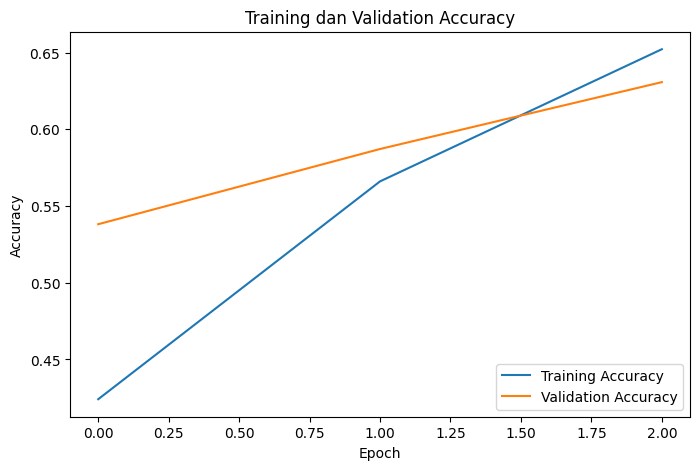

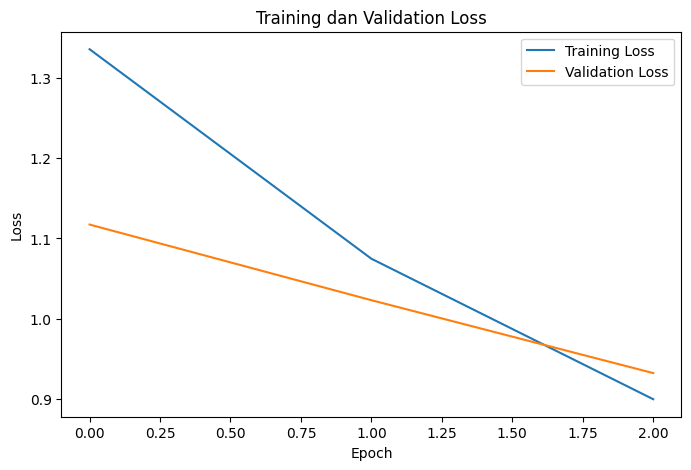

In [418]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(epochs)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


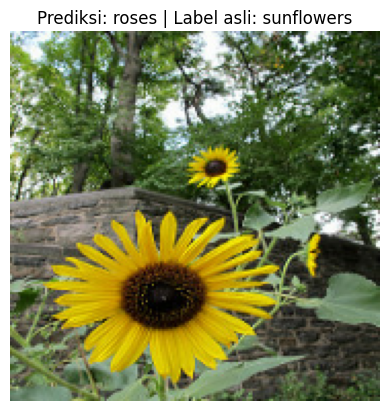

Probabilitas tiap kelas:
daisy       : 0.2009
dandelion   : 0.1822
roses       : 0.2338
sunflowers  : 0.2106
tulips      : 0.1725


In [425]:
for images, labels in val_ds.take(1):
    logits = model.predict(images)
    probabilities = tf.nn.softmax(logits)

    predicted_label = np.argmax(probabilities[0])
    true_label = labels[0].numpy()

    plt.imshow(images[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Prediksi: {class_names[predicted_label]} | Label asli: {class_names[true_label]}"
    )
    plt.show()

    print("Probabilitas tiap kelas:")
    for name, prob in zip(class_names, probabilities[0].numpy()):
        print(f"{name:12s}: {prob:.4f}")

In [423]:
img_path = "hibiscus.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "Gambar ini kemungkinan besar adalah {} dengan confidence {:.2f}%."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Gambar ini kemungkinan besar adalah roses dengan confidence 22.80%.


## Latihan 5. Gunakan Dataset Sendiri

Buat folder seperti ini:

```text
dataset_saya/
    kelas_1/
        gambar1.jpg
        gambar2.jpg
    kelas_2/
        gambar1.jpg
        gambar2.jpg
```

Lalu ubah:

```python
data_dir = pathlib.Path("dataset_saya")
```



In [426]:
import pathlib
import os

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


In [427]:
data_dir = pathlib.Path("/content/dataset_saya")
print(data_dir)

/content/dataset_saya


In [428]:
batch_size = 32
img_height = 180
img_width = 180

In [429]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4 files belonging to 2 classes.


In [430]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 4 files belonging to 2 classes.
Using 0 files for validation.


In [431]:
class_names = train_ds.class_names
print("Nama kelas:", class_names)

Nama kelas: ['kelas_1', 'kelas_2']


In [432]:
image_count = len(list(data_dir.glob("*/*.jpg")))
print("Jumlah gambar:", image_count)

Jumlah gambar: 4


Pertanyaan:

1. Apakah nama kelas terbaca otomatis?

   Jawaban : Ya,  nama kelas terbaca otomatis berdasarkan nama folder yang terdapat di dalam dataset_saya. Kelas yang terbaca adalah kelas_1 dan kelas_2

2. Apakah jumlah gambar setiap kelas seimbang?

   Jawaban : Ya, jumlah gambar setiap kelas seimbang dengan masing-masing folder untuk kelas_1 dan kelas_2 berisi 2 gambar

3. Apa yang terjadi jika satu kelas memiliki jauh lebih sedikit gambar?

   Jawaban : jika satu kelas memiliki jauh lebih sedikit gambar, model akan memiliki lebih sedikit contoh untuk mempelajari karakteristik kelas. Akibatnya model akan memprediksi kelas yang memiliki lebih banyak data sehingga akurasi pada kelas dengan jumlah gambar yang sedikit menjadi lebih rendah